# Customer Churn Prediction System
## Phase 3: Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Telco Customer Churn dataset.
The analysis is structured into three levels - Univariate, Bivariate, and Multivariate -
to understand data patterns, distributions, and relationships before model building.

## Setup - Import Libraries and Load Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load dataset
df = pd.read_csv('../data/telco_customer_churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Note:** The dataset has 7,043 rows and 21 columns. No preprocessing is applied here - this notebook is purely for exploratory analysis. Data cleaning and preprocessing will be performed in Phase 4.

---
## Univariate Analysis
Univariate analysis examines each feature individually to understand its distribution and frequency.

### Activity 1 - Distribution of Numerical Variables
Histograms show the spread and shape of each numerical feature.

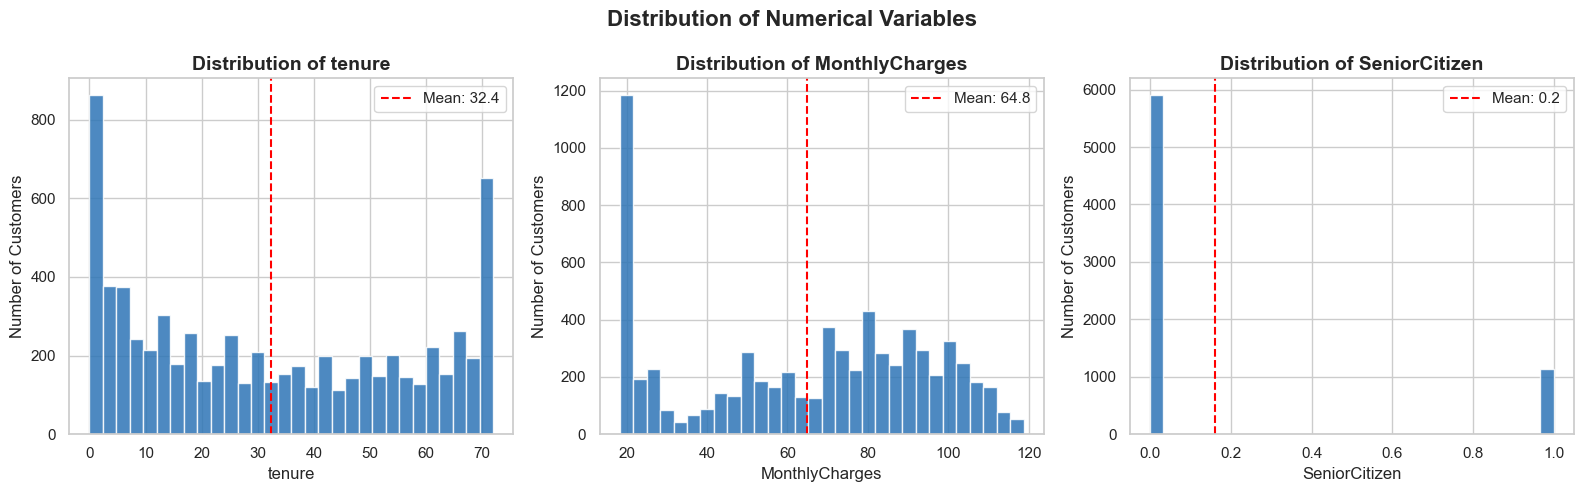

In [5]:
numerical_features = ['tenure', 'MonthlyCharges', 'SeniorCitizen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold')

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature], bins=30, color='#2E75B6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Number of Customers')
    mean_val = df[feature].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../outputs/univariate_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- **Tenure:** Distribution is spread across 0 - 72 months with peaks at both extremes, many very new customers and many long-term customers.
- **MonthlyCharges:** Shows two clusters - one around `$20` (basic plans) and another around `$70 – $90` (premium plans).
- **SeniorCitizen:** Heavily skewed - only ~16% of customers (mean = 0.16) are senior citizens.

### Activity 2 - Frequency of Categorical Variables
Countplots show how many customers fall into each category for every categorical feature.

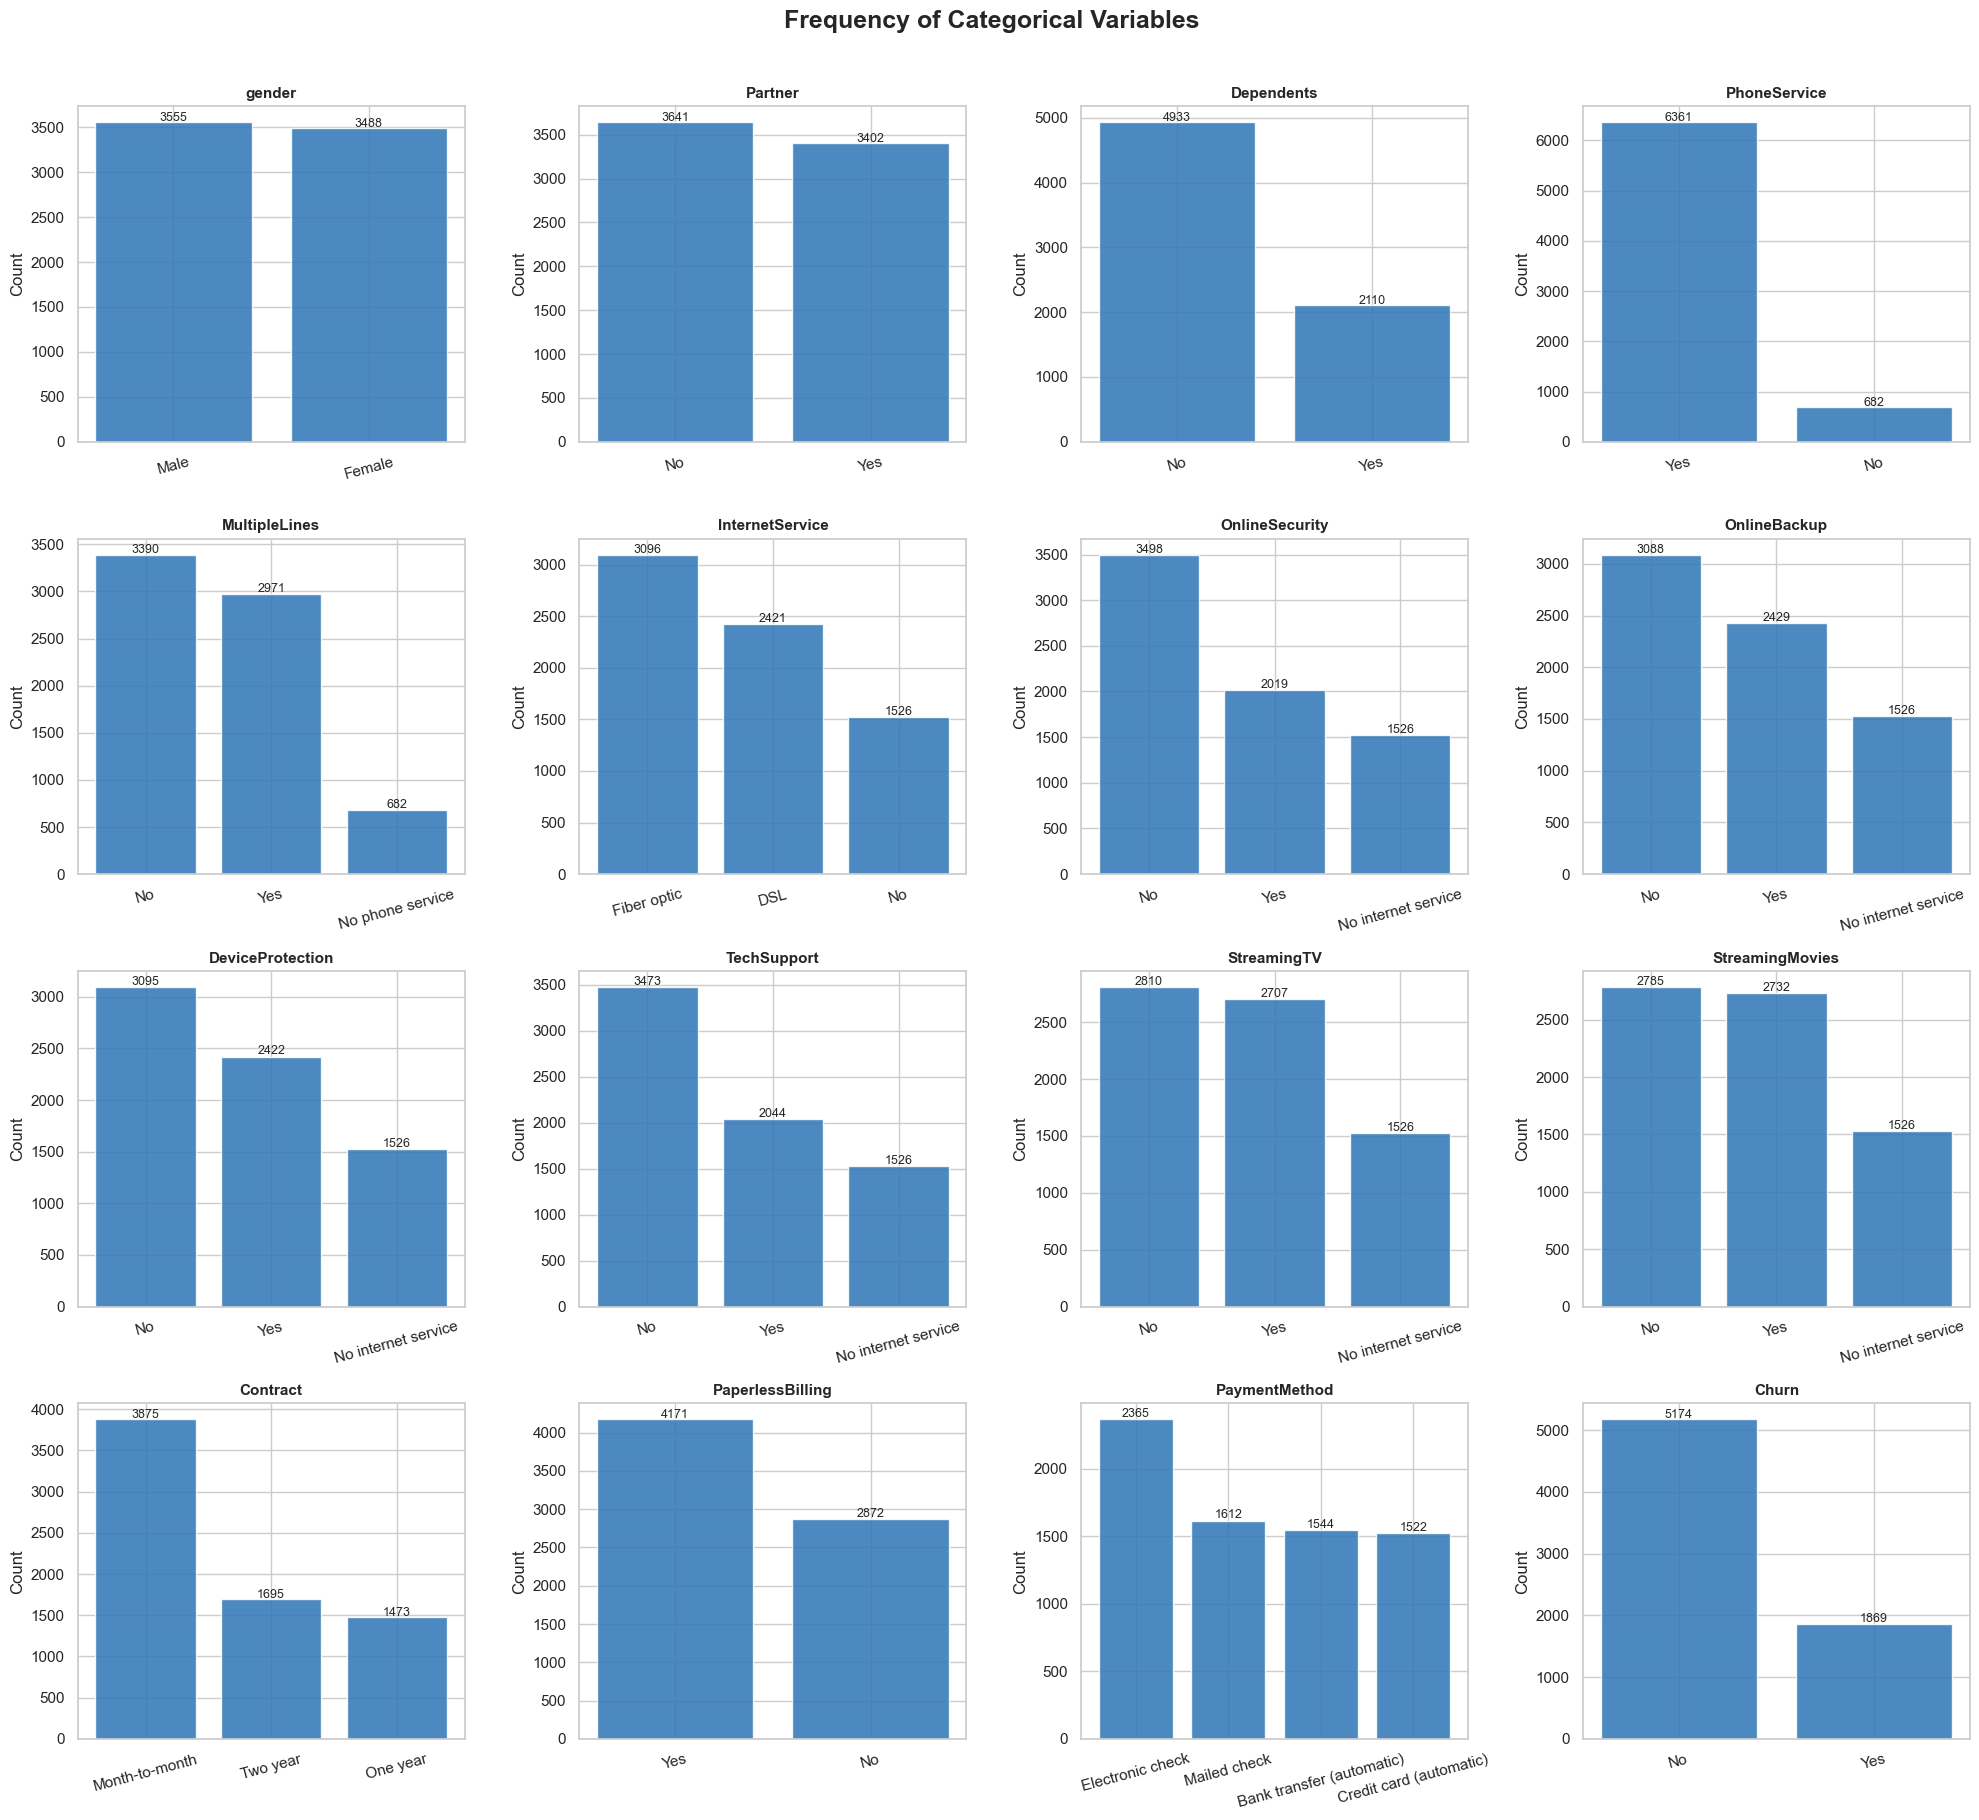

In [6]:
categorical_features = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
fig.suptitle('Frequency of Categorical Variables', fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    value_counts = df[feature].value_counts()
    axes[i].bar(value_counts.index, value_counts.values,
                color='#2E75B6', edgecolor='white', alpha=0.85)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/univariate_categorical_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- **Gender:** Nearly balanced - Male (3,555) vs Female (3,488).
- **Contract:** Month-to-month is the most common contract type (3,875 customers).
- **InternetService:** Fiber optic is the most subscribed internet plan (3,096 customers).
- **PaymentMethod:** Electronic check is the most used payment method (2,365 customers).
- **Churn:** 5,174 customers stayed (No) vs 1,869 churned (Yes) - dataset is moderately imbalanced.

---
## Bivariate Analysis
Bivariate analysis examines the relationship between individual features and the target variable Churn.

### Activity 3 - Churn vs Contract Type

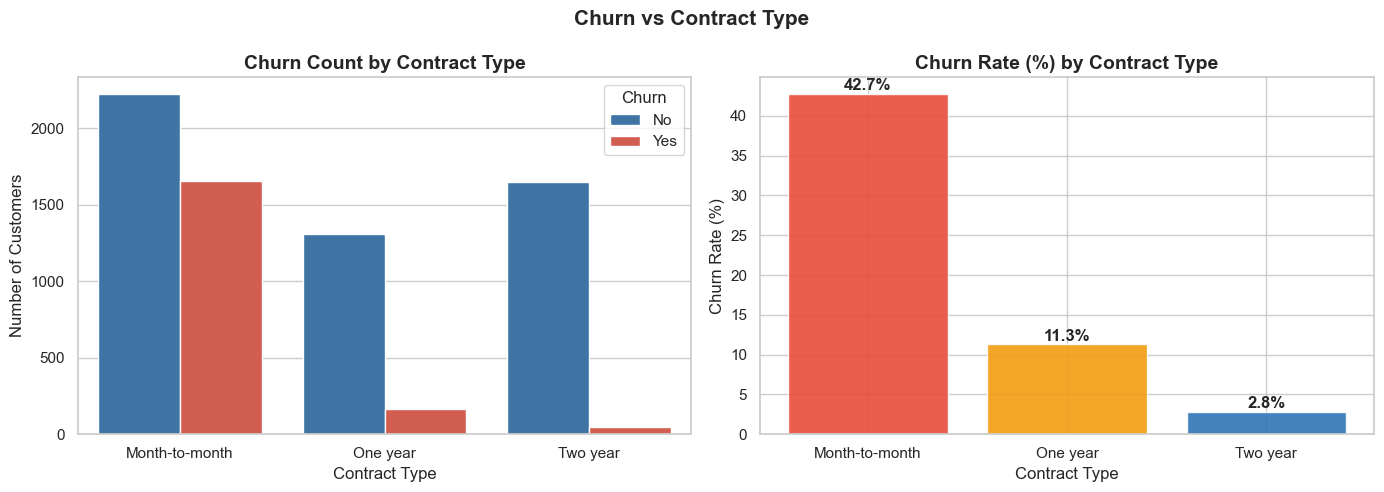

      Contract  Churn Rate (%)
Month-to-month       42.709677
      One year       11.269518
      Two year        2.831858


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Contract Type', fontsize=15, fontweight='bold')

# Countplot
sns.countplot(data=df, x='Contract', hue='Churn',
              palette={'Yes': '#E74C3C', 'No': '#2E75B6'},
              ax=axes[0], edgecolor='white')
axes[0].set_title('Churn Count by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn')

# Churn rate per contract type
churn_rate = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
churn_rate.columns = ['Contract', 'Churn Rate (%)']

bars = axes[1].bar(churn_rate['Contract'], churn_rate['Churn Rate (%)'],
                   color=['#E74C3C', '#F39C12', '#2E75B6'],
                   edgecolor='white', alpha=0.9)
axes[1].set_title('Churn Rate (%) by Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/bivariate_churn_vs_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print(churn_rate.to_string(index=False))

**Observation:**
- Month-to-month customers churn at `~42%` - nearly 3x higher than one-year contracts `(~11%)` and over 6x higher than two-year contracts `(~3%)`.
- Customers on longer contracts are significantly more committed and less likely to leave.
- **Business Insight:** Encouraging customers to move from month-to-month to longer contracts is the single most impactful retention strategy.

### Activity 4 - Churn vs Monthly Charges

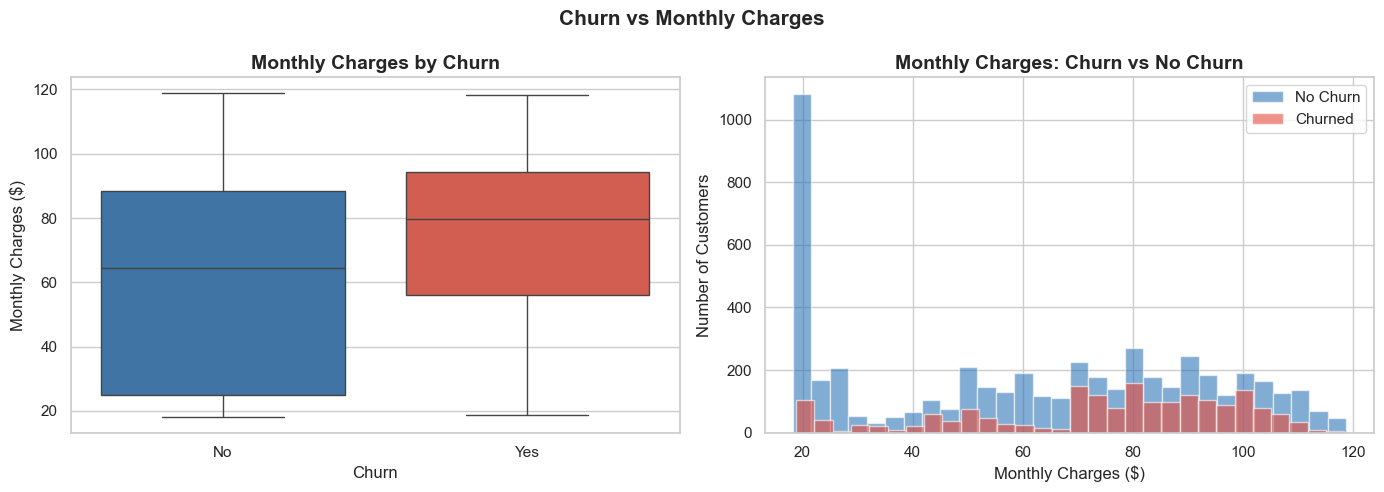

Average Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Monthly Charges', fontsize=15, fontweight='bold')

# Boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette={'Yes': '#E74C3C', 'No': '#2E75B6'}, legend=False, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

# Histogram overlay
axes[1].hist(df[df['Churn'] == 'No']['MonthlyCharges'], bins=30,
             alpha=0.6, color='#2E75B6', label='No Churn', edgecolor='white')
axes[1].hist(df[df['Churn'] == 'Yes']['MonthlyCharges'], bins=30,
             alpha=0.6, color='#E74C3C', label='Churned', edgecolor='white')
axes[1].set_title('Monthly Charges: Churn vs No Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/bivariate_churn_vs_monthlycharges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average Monthly Charges by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

**Observation:**
- Churned customers have a higher median monthly charge `(~$74)` compared to retained customers `(~$61)`.
- The histogram shows churned customers are concentrated in the `$60 – $100` range.
- **Business Insight:** High-charge customers are at elevated churn risk. Targeted retention offers for customers paying above $70/month could reduce churn.

### Activity 5 - Churn vs Tenure

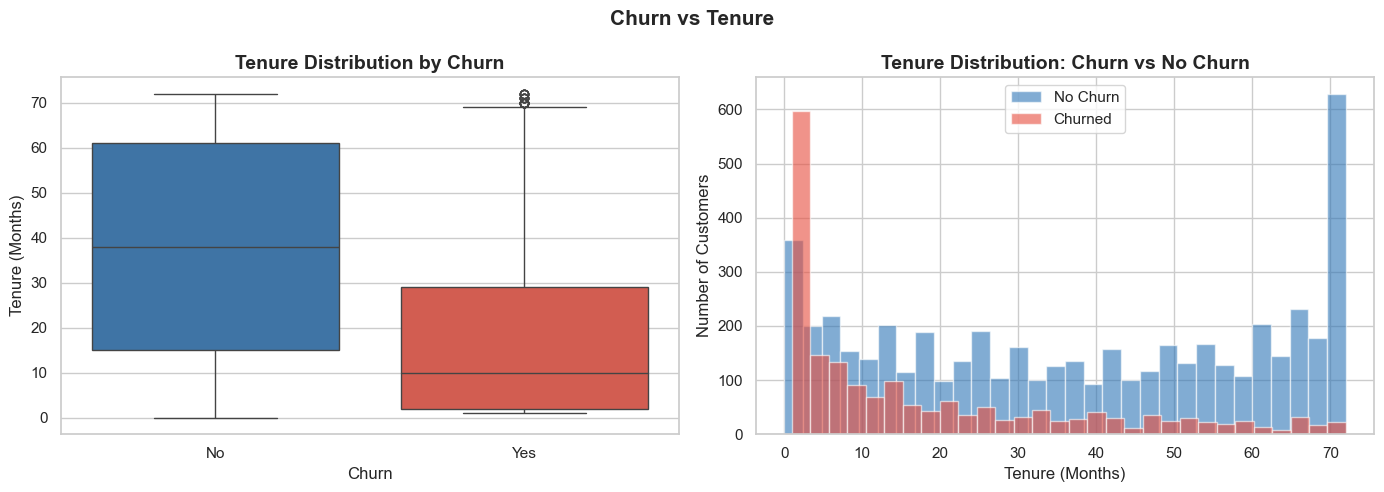

Average Tenure by Churn:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Tenure', fontsize=15, fontweight='bold')

# Boxplot
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn',
            palette={'Yes': '#E74C3C', 'No': '#2E75B6'}, legend=False, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (Months)')

# Histogram overlay
axes[1].hist(df[df['Churn'] == 'No']['tenure'], bins=30,
             alpha=0.6, color='#2E75B6', label='No Churn', edgecolor='white')
axes[1].hist(df[df['Churn'] == 'Yes']['tenure'], bins=30,
             alpha=0.6, color='#E74C3C', label='Churned', edgecolor='white')
axes[1].set_title('Tenure Distribution: Churn vs No Churn')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/bivariate_churn_vs_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average Tenure by Churn:")
print(df.groupby('Churn')['tenure'].mean().round(2))

**Observation:**
- Churned customers have a much lower median tenure `(~18 months)` compared to retained customers `(~38 months)`.
- Churned customers are heavily concentrated in the first 0–20 months.
- **Business Insight:** The first 12 months is the highest-risk churn period. An early engagement programme targeting new customers could significantly reduce churn.

---
## Multivariate Analysis
Multivariate analysis examines relationships between multiple features simultaneously.

### Activity 6 - Correlation Matrix

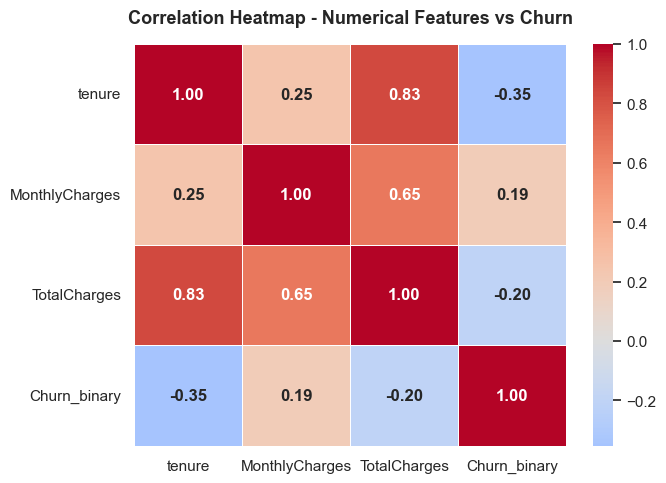

Correlation with Churn:
MonthlyCharges    0.193356
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_binary, dtype: float64


In [17]:
# Encode Churn as binary for correlation
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

# Convert TotalCharges to numeric (has blank strings — coerce handles them)
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Features vs Churn',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/multivariate_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with Churn:")
print(corr_matrix['Churn_binary'].drop('Churn_binary').sort_values(ascending=False))

**Observation:**
- **tenure** has the strongest negative correlation with Churn (-0.35) - the longer a customer stays, the less likely they are to churn.
- **MonthlyCharges** has a positive correlation with Churn (+0.19) - higher charges are linked to higher churn risk.
- **TotalCharges** has a negative correlation with Churn (-0.20) - customers with higher total charges (long-term customers) are less likely to churn.
- **TotalCharges and tenure are highly correlated (+0.83)** - this is expected since TotalCharges accumulates over time. One of these may be dropped during feature selection to avoid multicollinearity.

### Activity 7 - Feature Relationships (Pairplot)

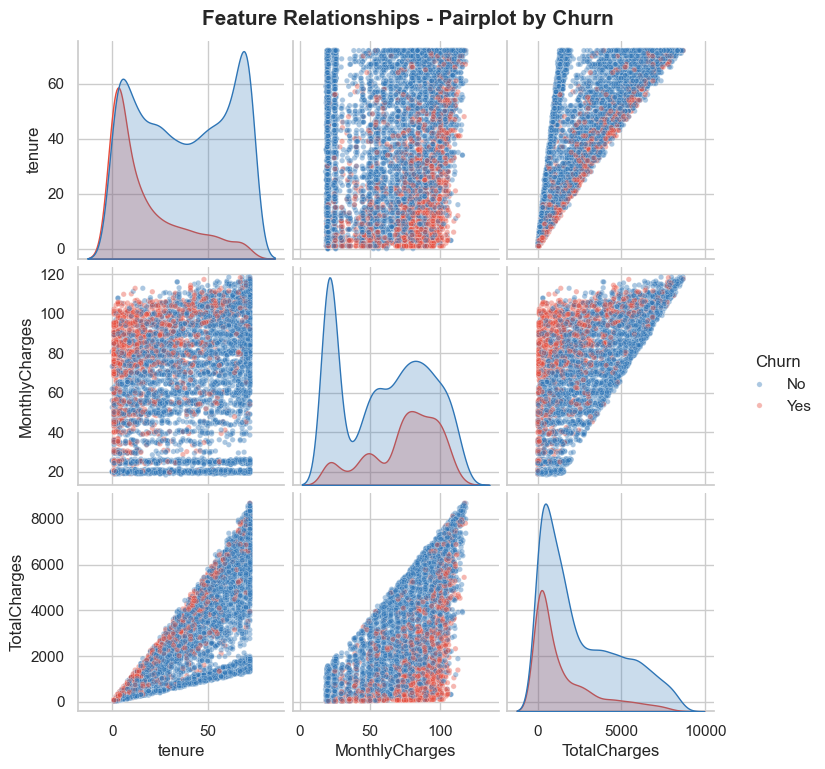

In [19]:
df_pair = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()

# Convert TotalCharges to numeric for plotting
df_pair['TotalCharges'] = pd.to_numeric(df_pair['TotalCharges'], errors='coerce')

pairplot = sns.pairplot(df_pair, hue='Churn',
                        palette={'Yes': '#E74C3C', 'No': '#2E75B6'},
                        plot_kws={'alpha': 0.4, 's': 15},
                        diag_kind='kde')
pairplot.figure.suptitle('Feature Relationships - Pairplot by Churn',
                          y=1.02, fontsize=15, fontweight='bold')

plt.savefig('../outputs/multivariate_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- The tenure vs MonthlyCharges scatter clearly shows churned customers (red) clustered at low tenure and high monthly charges - confirming this is the highest-risk customer profile.
- TotalCharges vs tenure shows a near-linear relationship (+0.83 correlation) - customers with high TotalCharges are almost always long-tenure customers who are less likely to churn.
- KDE diagonal plots confirm churned customers skew toward lower tenure, lower TotalCharges, and higher MonthlyCharges compared to retained customers.

---
## Key Business Insights

1. **Contract type is the strongest churn predictor** : Month-to-month customers churn at ~42% vs ~11% (one-year) and ~3% (two-year). Encouraging longer contracts is the most impactful retention strategy.

2. **New customers are the highest-risk group** : Churned customers have a median tenure of only ~18 months. The first 12 months is the critical retention window.

3. **High monthly charges increase churn risk** : Churned customers pay `~$74/month` on average vs `~$61` for retained customers. Customers above `$70/month` need targeted retention attention.

4. **Tenure is the strongest numerical predictor of churn** : Negative correlation of -0.35. The longer a customer stays, the less likely they are to leave.

5. **Low TotalCharges signals high churn risk** : TotalCharges has a negative correlation with churn (-0.20). Customers with low total billing history (new or low-spend customers) are more likely to churn.

6. **TotalCharges and tenure are highly correlated (+0.83)** : Both features carry similar information. One may need to be dropped during feature selection in Phase 5 to avoid multicollinearity.

7. **Fiber optic internet customers churn more** : Despite being the premium service, fiber optic customers show higher churn rates, possibly due to higher associated monthly charges.

8. **Low tenure + high monthly charges = highest risk combination** : Clearly visible in the pairplot. Customers new to the service but on expensive plans are the most likely to churn and should be the primary focus of retention campaigns.